# Post Lab: Regression on California Housing Dataset

Dataset Shape: (20640, 8)
Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Model Performance:

Linear Regression 244EU02011
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R² Score : 0.5758
Support Vector Regression 24EU02011
MAE  : 0.3717
MSE  : 0.3201
RMSE : 0.5658
R² Score : 0.7557
Decision Tree Regression 24EU02011
MAE  : 0.4547
MSE  : 0.4952
RMSE : 0.7037
R² Score : 0.6221


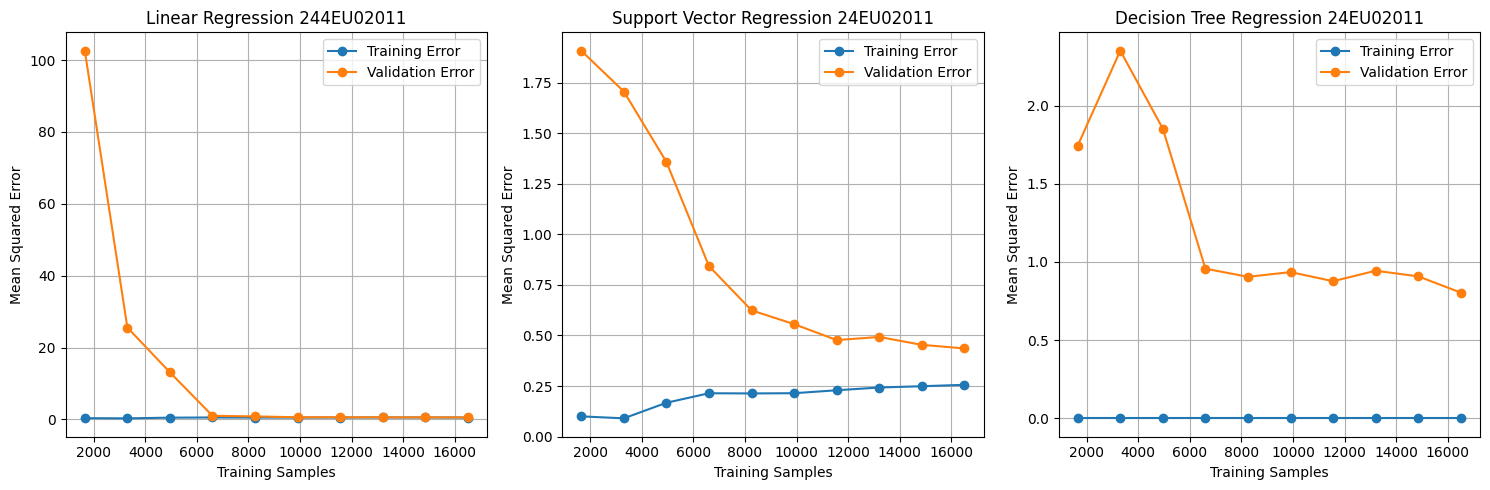

In [ ]:


import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# Load California Housing Dataset
# -----------------------------
housing = fetch_california_housing()
X = housing.data
y = housing.target

print("Dataset Shape:", X.shape)
print("Feature Names:", housing.feature_names)

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Define Models
# -----------------------------
models = {
    "Linear Regression 244EU02011": LinearRegression(),
    "Support Vector Regression 24EU02011": make_pipeline(
        StandardScaler(), SVR(kernel='rbf', C=100, gamma='scale')
    ),
    "Decision Tree Regression 24EU02011": DecisionTreeRegressor(random_state=42)
}


print("\nModel Performance:\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("="*50)
    print(name)
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R² Score : {r2:.4f}")

plt.figure(figsize=(15, 5))

for i, (name, model) in enumerate(models.items(), 1):

    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_error = -train_scores.mean(axis=1)
    test_error = -test_scores.mean(axis=1)

    plt.subplot(1, 3, i)
    plt.plot(train_sizes, train_error, 'o-', label='Training Error')
    plt.plot(train_sizes, test_error, 'o-', label='Validation Error')
    plt.title(name)
    plt.xlabel("Training Samples")
    plt.ylabel("Mean Squared Error")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()